Q1 part a


In [ ]:

import math

#Compute and print Standard Error (SE)
sample_std = 1.8
n = 30
SE = sample_std / math.sqrt(n)
print("Standard Error (SE):", SE)

sample_mean = 5.5
z_score = 1.96  # for 95% confidence interval
LB = sample_mean - z_score * SE
UB = sample_mean + z_score * SE
print("Lower Bound (LB):", LB)
print("Upper Bound (UB):", UB)


Standard Error (SE): 0.3286335345030997
Lower Bound (LB): 4.855878272373925
Upper Bound (UB): 6.144121727626075


part c

In [ ]:

sample_mean = 5.5
sample_std = 1.8
n = 30
z_score = 1.96  # for 95% confidence interval

margin_of_error = z_score * (sample_std / math.sqrt(n))
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("Confidence Interval (Manual calculation):", confidence_interval)


Confidence Interval (Manual calculation): (4.855878272373925, 6.144121727626075)


q2 part a

In [ ]:

import math

p_hat = 420 / 600
n = 600
SE = math.sqrt((p_hat * (1 - p_hat)) / n)
print("Standard Error (SE):", SE)

z_score = 1.96  # for 95% confidence interval
LB = p_hat - z_score * SE
UB = p_hat + z_score * SE
print("Lower Bound (LB):", LB)
print("Upper Bound (UB):", UB)


Standard Error (SE): 0.01870828693386971
Lower Bound (LB): 0.6633317576096154
Upper Bound (UB): 0.7366682423903845


part c

In [ ]:
# Part C: Python

# vii. Compute interval using statistics Library
import statistics

p_hat = 420 / 600
confidence_interval = 1.96 * math.sqrt((p_hat * (1 - p_hat)) / 600)
print("Confidence Interval (Using statistics library):", confidence_interval)


Confidence Interval (Using statistics library): 0.03666824239038463


Q3

In [ ]:
# i. Import necessary packages
import pandas as pd
import math

# ii. Load dataset and print first five rows
data = pd.read_csv("/content/Life_Expectancy_Data.csv - Life_Expectancy_Data.csv.csv")
print("First five rows of the dataset:")
print(data.head())

bmi_mean = data['BMI'].mean()
bmi_std = data['BMI'].std()
bmi_size = len(data['BMI'])
print("\nStatistics for 'BMI' feature:")
print("Mean:", bmi_mean)
print("Standard Deviation:", bmi_std)
print("Size (n):", bmi_size)
]
bmi_se = bmi_std / math.sqrt(bmi_size)
print("\nStandard Error (SE) for 'BMI' feature:", bmi_se)

# vi. Compute and print upper bound (UB) and lower bound (LB) [using BMI feature]
z_score = 1.96  # for 95% confidence interval
bmi_lb = bmi_mean - z_score * bmi_se
bmi_ub = bmi_mean + z_score * bmi_se
print("\nLower Bound (LB) for 'BMI' feature:", bmi_lb)
print("Upper Bound (UB) for 'BMI' feature:", bmi_ub)


First five rows of the dataset:
       Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0              263   
1  Afghanistan  2014  Developing             59.9              271   
2  Afghanistan  2013  Developing             59.9              268   
3  Afghanistan  2012  Developing             59.5              272   
4  Afghanistan  2011  Developing             59.2              275   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624           65     1154  ...   
1             64     0.01               73.523582           62      492  ...   
2             66     0.01               73.219243           64      430  ...   
3             69     0.01               78.184215           67     2787  ...   
4             71     0.01                7.097109           68     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Pop

Q4

First five rows of the dataset:
   Id  LotArea  SalePrice
0   0     8450   208500.0
1   1     9600   181500.0
2   2    11250   223500.0
3   3     9550   140000.0
4   4    14260   250000.0


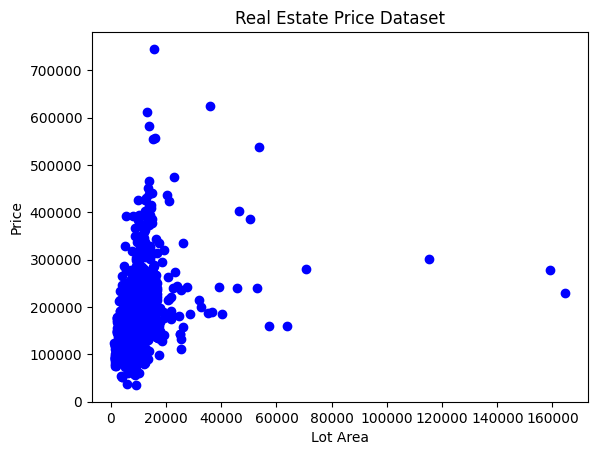

In [1]:
# Tasks I: Python

# i. Load dataset (Real_Estate_Price.csv) and print first five rows
import pandas as pd

data = pd.read_csv("/content/Real_Estate_Price.xlsx - Sheet1.csv")
print("First five rows of the dataset:")
print(data.head())

# ii. Split the data set into training and test data 75% and 25% respectively
from sklearn.model_selection import train_test_split

X = data[['LotArea']]
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# iii. Draw feature space (Scatter Plot)
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='blue')
plt.title('Real Estate Price Dataset')
plt.xlabel('Lot Area')
plt.ylabel('Price')
plt.show()


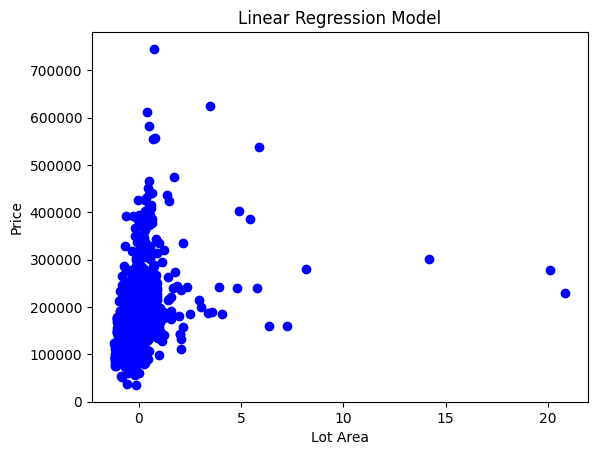

Coefficients: [nan nan]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Tasks II: Python

# I. Normalize data (if required)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# II. Implement prediction function
def predict(X, theta):
    return np.dot(X, theta)

# III. Implement Risk function (Mean Squared Error)
def risk(X, y, theta):
    m = len(y)
    return np.sum((predict(X, theta) - y) ** 2) / (2 * m)

# IV. Implement Gradient Descent function
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    history = []
    for i in range(iterations):
        theta = theta - (alpha / m) * np.dot(X.T, (predict(X, theta) - y))
        history.append((theta, risk(X, y, theta)))
    return theta, history

# Initialize theta (parameters)
theta = np.zeros(X_train_scaled.shape[1] + 1)
X_train_scaled_with_bias = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]

# Hyperparameters
alpha = 0.01
iterations = 1000

# Train the model
theta_final, history = gradient_descent(X_train_scaled_with_bias, y_train.values, theta, alpha, iterations)

# V. Plot the LR model (predicted values) with x-axis and y-axis
plt.scatter(X_train_scaled, y_train, color='blue')
plt.plot(X_train_scaled, predict(X_train_scaled_with_bias, theta_final), color='red')
plt.xlabel('Lot Area')
plt.ylabel('Price')
plt.title('Linear Regression Model')
plt.show()

# VI. Print coefficients
print("Coefficients:", theta_final)


**PART 2**

Q1

part a

**Step 1: Population of Interest:**

The population of interest consists of individuals who have tried the specific brand of energy drink.


**Step 2: Null Hypothesis:**

𝐻0:
The proportion of consumers who experience a boost in energy levels after consuming the energy drink is less than or equal to 65%.

**Step 3: Alternative Hypothesis:**

𝐻1:
 The proportion of consumers who experience a boost in energy levels after consuming the energy drink is greater than 65%.

**part b**

In [ ]:
# Import necessary packages
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

successes = 990
# Total number of trials (individuals surveyed)
nobs = 1500
# Null hypothesis proportion (proportion claimed by the company)
p_null = 0.65

# Perform one-sample z-test
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs, value=p_null, alternative='larger')

# Print z-test statistic and p-value
print("Population proportion z-test statistic:", z_stat)
print("P-value:", p_value)


Population proportion z-test statistic: 0.8175874252096615
P-value: 0.20679640511351505


**Q2 part a**

**Step 1: Population of Interest:**

Population of interest consists of all member countries of the United Nations who participated in the survey.

**Step 2: Null Hypothesis:**

H0:The mean health 'percentage expenditure' of the world is greater than or equal to 500.

**Step 3: Alternative Hypothesis:**

H1:The mean health 'percentage expenditure' of the world is less than 500.

**Q2 part b**

In [ ]:
# Part B: Python

# i. Import necessary packages
import pandas as pd
import statistics

# ii. Load dataset (Life_Expectancy_Data.csv) and print first five rows
data = pd.read_csv("/content/Life_Expectancy_Data.csv - Life_Expectancy_Data.csv.csv")
print("First five rows of the dataset:")
print(data.head())

# iii. Compute and print mean, Standard Deviation, and size (n) of “percentage expenditure” feature
mean_percentage_expenditure = data['percentage expenditure'].mean()
std_percentage_expenditure = data['percentage expenditure'].std()
n = len(data['percentage expenditure'])
print("\nStatistics for 'percentage expenditure' feature:")
print("Mean:", mean_percentage_expenditure)
print("Standard Deviation:", std_percentage_expenditure)
print("Size (n):", n)

# iv. Compute and print Z-Test
z_stat = (mean_percentage_expenditure - 500) / (std_percentage_expenditure / (n ** 0.5))
p_value = statistics.NormalDist().cdf(z_stat)
print("\nZ-Test statistic:", z_stat)
print("P-value:", p_value)


First five rows of the dataset:
       Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0              263   
1  Afghanistan  2014  Developing             59.9              271   
2  Afghanistan  2013  Developing             59.9              268   
3  Afghanistan  2012  Developing             59.5              272   
4  Afghanistan  2011  Developing             59.2              275   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624           65     1154  ...   
1             64     0.01               73.523582           62      492  ...   
2             66     0.01               73.219243           64      430  ...   
3             69     0.01               78.184215           67     2787  ...   
4             71     0.01                7.097109           68     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Pop

**part c**

**Decision:**
Since the p-value obtained from the Z-Test is greater than the significance level (0.05), we dont reject the null hypothesis. Therefore, we conclude that the mean health 'percentage expenditure' of the world is statistically significantly less than 500.


**Q3**

part **a**

**Step 1: Population of Interest:**

The population of interest consists of all individuals represented in the dataset.

**Step 2: Null Hypothesis:**

H0:There is no significant difference in the BMI between males and females.
Null Hypothesis (H0):
𝜇male=𝜇female​

**Step 3: Alternative Hypothesis:**

H1:The BMI of males is significantly higher than females.
Alternative Hypothesis (𝐻1):
𝜇male>𝜇female


part **b**

In [ ]:
# Part B: Python

# i. Import necessary packages
import pandas as pd
from scipy import stats

# ii. Load dataset (BMIdataset.csv) and print first five rows
data = pd.read_csv("/content/BMIDataset.csv - BMIDataset.csv.csv")
print("First five rows of the dataset:")
print(data.head())

# iii. Compute Two lists for “male_bmi” and “female_bmi” using the status feature
male_bmi = data[data['Sex'] == 0]['BMI']
female_bmi = data[data['Sex'] == 1]['BMI']

# iv. Compute and print mean, Standard Deviation, and size (n) of “BMI” of females
mean_female_bmi = female_bmi.mean()
std_female_bmi = female_bmi.std()
n_female_bmi = len(female_bmi)
print("\nStatistics for 'BMI' of females:")
print("Mean:", mean_female_bmi)
print("Standard Deviation:", std_female_bmi)
print("Size (n):", n_female_bmi)

# v. Compute and print mean, Standard Deviation, and size (n) of “BMI” of males
mean_male_bmi = male_bmi.mean()
std_male_bmi = male_bmi.std()
n_male_bmi = len(male_bmi)
print("\nStatistics for 'BMI' of males:")
print("Mean:", mean_male_bmi)
print("Standard Deviation:", std_male_bmi)
print("Size (n):", n_male_bmi)

# vi. Compute and print p-value and z-statistics using Statistics Library (Z-Test for two populations)
z_stat, p_value = stats.ttest_ind(male_bmi, female_bmi)
print("\nZ-Test statistic:", z_stat)
print("P-value:", p_value)


First five rows of the dataset:
   SID   BMI  Sex         Steps         THR     FatBurn     Cardio      Peak  \
0    1  14.5    0   8244.168142  110.327434  108.168142   2.097345  0.061947   
1    2  15.7    0   8888.471545  347.089431  338.130081   8.487805  0.471545   
2    3  15.8    0  15412.228070  138.052632  123.850877   9.535088  4.666667   
3    4  15.8    0  13337.075470  145.518868  133.924528   9.443396  2.150943   
4    5  15.9    1  11913.763640  230.881818  210.118182  15.900000  4.863636   

   Age Class  
0   18    FR  
1   18    FR  
2   19    FR  
3   19    SO  
4   19    SO  

Statistics for 'BMI' of females:
Mean: 24.77132459970888
Standard Deviation: 4.764874683574225
Size (n): 687

Statistics for 'BMI' of males:
Mean: 24.494075403949733
Standard Deviation: 5.417387475517847
Size (n): 1114

Z-Test statistic: -1.1036950596779083
P-value: 0.2698730465642939


**Decision:**
Since the p-value obtained from the Z-Test is  greater than the significance level (0.05), we do not reject the null hypothesis. Therefore, we conclude that there is insufficient evidence to conclude that the BMI of males is significantly higher than females based on this dataset.
